# Benchmark de configuraciones de simulación — Columna de adsorción 1D

## Objetivo

Evaluar de forma sistemática el comportamiento numérico, físico y computacional
del modelo de columna de adsorción bajo diferentes combinaciones de:

- **Modelo de propiedades del gas** (`fixed`, `constant`, `polynomial`)
- **Política de actualización de propiedades** (`prop_update_mode`: `frozen` / `always`)
- **Política de actualización de transporte** (`trans_update_mode`: `frozen` / `always`)
- **Condición térmica de pared** (`adiabatic` / `ambient_htc`)

Los casos se generan por **producto cartesiano** de los ejes de variación configurables.
Todos comparten geometría, isotermas, condiciones iniciales y de contorno, por lo que
cualquier diferencia se atribuye exclusivamente al tratamiento de propiedades.

## Métricas evaluadas

| Grupo | Indicadores |
|-------|-------------|
| Rendimiento | Tiempo de pared [s], top funciones más costosas |
| Cierre de balances | Error molar rel. [%], error energético rel. [%] |
| Estado final | P media [bar], Tg media [K], Ts media [K] |
| Perfiles axiales | Tg y P al final del paso, coloreados por caso |

## Flujo del notebook

1. Imports + isotermas + geometría (una sola vez)
2. Definir matriz de casos
3. `build_params(case)` → `run_step()` → `balance_report()` por caso
4. Dashboard visual: tabla coloreada, timing, balances, perfiles

In [1]:
import os, sys, time, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.utils.profiling import (
    set_develop, set_benchmark, reset_benchmark, print_benchmark_functions
)
from src.utils.isotherm_fitting import fit_single_T
from src.utils.isotherm_models  import arrh

from src.units.adsorber.config.gas_props  import build_gas_prop_config
from src.units.adsorber.config.adsorbent  import build_adsorbent_config
from src.units.adsorber.config.transport  import build_transport_config
from src.units.adsorber.config.thermal_bc import build_thermal_bc_config
from src.units.adsorber.config.boundary_c import build_boundary_c_config
from src.units.adsorber.config.initial_c  import build_initial_c_config
from src.units.adsorber.state import pack_state_vector

from src.solvers.runner_adsorption import run_step
from src.postprocessing.adsorber_balances   import balance_report

DB_PATH   = os.path.join(ROOT, "materials", "fluids", "gasdb.txt")
DATA_PATH = os.path.join(os.getcwd(), "data", "Zeolite13X.csv")

print("Imports OK")
print("gasdb existe :", os.path.isfile(DB_PATH))
print("datos existen:", os.path.isfile(DATA_PATH))

Imports OK
gasdb existe : True
datos existen: True


In [2]:
# ── Ajuste de isotermas ───────────────────────────────────────────────────
df_iso = pd.read_csv(DATA_PATH)
P_CO2  = df_iso["Pressure_CO2 (bar)"].dropna().values
q_CO2  = df_iso["Uptake_CO2 (mol/kg)"].dropna().values
P_CH4  = df_iso["Pressure_CH4 (bar)"].dropna().values
q_CH4  = df_iso["Uptake_CH4 (mol/kg)"].dropna().values

T_REF  = 298.15    # [K]
dH_CO2 = 31.164e3  # [J/mol]
dH_CH4 =  9.856e3  # [J/mol]

iso_CO2_P, par_CO2, name_CO2, _ = fit_single_T(P_CO2, q_CO2)
iso_CH4_P, par_CH4, name_CH4, _ = fit_single_T(P_CH4, q_CH4)

def iso_CO2_PT(P_bar, T_K):
    return iso_CO2_P(np.asarray(P_bar) * arrh(float(T_K), dH_CO2, T_REF))

def iso_CH4_PT(P_bar, T_K):
    return iso_CH4_P(np.asarray(P_bar) * arrh(float(T_K), dH_CH4, T_REF))

def iso_fn_psa(P_part_list, Ts):
    Ts_arr = np.asarray(Ts, dtype=float)
    N_loc  = len(Ts_arr)
    q_eq   = np.zeros((2, N_loc), dtype=float)
    for n in range(N_loc):
        q_eq[0, n] = iso_CO2_PT(float(P_part_list[0][n]), Ts_arr[n])
        q_eq[1, n] = iso_CH4_PT(float(P_part_list[1][n]), Ts_arr[n])
    return q_eq

print(f"CO2 → {name_CO2}  |  CH4 → {name_CH4}")

CO2 → Dual-site Langmuir  |  CH4 → Dual-site Langmuir


In [3]:
# ── Geometría y parámetros fijos (compartidos por todos los casos) ─────────
N    = 21
L    = 1.35       # m
Di   = 0.30       # m
Do   = 0.35       # m
dz   = L / N      # m
Ai   = 0.25 * np.pi * Di**2
Pi   = np.pi * Di
Po   = np.pi * Do
e_wall = (Do - Di) / 2.0

nc        = 2
SPECIES   = ["CO2", "CH4"]
epsi      = 0.37
D_particle = 12.0e-4   # m
rho_s     = 3200.0     # kg/m3
Cp_s      = 1200.0     # J/kg/K
k_s       = 10.0       # W/m/K
tau_pore  = 3.0
r_pore    = 1.0e-9     # m
dH_ads    = np.array([dH_CO2, dH_CH4])

P_inlet   = 9.5        # bar
P_outlet  = 9.0        # bar
T_feed    = 323.0      # K
y_feed    = np.array([0.33, 0.67])
Cv_outlet = 1.5
Cv_inlet  = 2.5e-1
Q_feed    = 0.05 * Ai  # m3/s

# Propiedades fijas manuales (para modo fixed)
PROP_GAS_FIXED = {
    "species":  SPECIES,
    "MW":       np.array([0.044, 0.016]),
    "mu":       np.array([16.13e-6, 11.86e-6]),
    "k":        np.array([0.0160, 0.0339]),
    "Cp_molar": np.array([38.236, 35.8]),
    "h_molar":  np.array([0.0, 0.0]),
    "sigmaLJ":  np.array([3.941, 3.758]),
    "epskB":    np.array([195.2, 148.6]),
    "Tref":     np.array([T_REF, T_REF]),
    "Tmax":     np.array([1000.0, 1000.0]),
}

print(f"Geometría OK | N={N} | dz={dz:.4f} m | Ai={Ai:.5f} m²")

Geometría OK | N=21 | dz=0.0643 m | Ai=0.07069 m²


## Configuración de la matriz de casos

Modifica las listas de abajo para añadir o quitar ejes de variación.
El producto cartesiano se calcula automáticamente.

- `GAS_MODES`: modelo de propiedades puras del gas
- `PROP_UPDATE_MODES`: política de actualización de propiedades en RHS
- `TRANS_UPDATE_MODES`: política de actualización de transporte
- `WALL_MODES`: condición térmica de la pared

In [4]:
# ── Ejes de variación (editar aquí para añadir/quitar casos) ─────────────
GAS_MODES          = ["fixed", "constant", "polynomial"]
PROP_UPDATE_MODES  = ["frozen", "always"]
TRANS_UPDATE_MODES = ["frozen", "always"]
WALL_MODES         = ["adiabatic", "ambient_htc"]

# ── Parámetros del integrador ODE (iguales para todos los casos) ──────────
T_MAX  = 600.0    # s
N_SEC  = 20       # puntos de salida por segundo
RTOL   = 1.0e-8
ATOL   = 1.0e-10
SOLVER = "solve_ivp"

# ── Construcción automática de la lista de casos ──────────────────────────
CASES = []
for gas_m, prop_u, trans_u, wall_m in itertools.product(
    GAS_MODES, PROP_UPDATE_MODES, TRANS_UPDATE_MODES, WALL_MODES
):
    name  = f"{gas_m}__{prop_u}__{trans_u}__{wall_m}"
    label = f"{gas_m[:3]}/{prop_u[:3]}/{trans_u[:3]}/{wall_m[:4]}"
    CASES.append({
        "name":              name,
        "label":             label,
        "gas_mode":          gas_m,
        "prop_update_mode":  prop_u,
        "trans_update_mode": trans_u,
        "wall_mode":         wall_m,
    })

print(f"Total de casos a ejecutar: {len(CASES)}")
print()
for c in CASES:
    print(f"  {c['name']}")

Total de casos a ejecutar: 24

  fixed__frozen__frozen__adiabatic
  fixed__frozen__frozen__ambient_htc
  fixed__frozen__always__adiabatic
  fixed__frozen__always__ambient_htc
  fixed__always__frozen__adiabatic
  fixed__always__frozen__ambient_htc
  fixed__always__always__adiabatic
  fixed__always__always__ambient_htc
  constant__frozen__frozen__adiabatic
  constant__frozen__frozen__ambient_htc
  constant__frozen__always__adiabatic
  constant__frozen__always__ambient_htc
  constant__always__frozen__adiabatic
  constant__always__frozen__ambient_htc
  constant__always__always__adiabatic
  constant__always__always__ambient_htc
  polynomial__frozen__frozen__adiabatic
  polynomial__frozen__frozen__ambient_htc
  polynomial__frozen__always__adiabatic
  polynomial__frozen__always__ambient_htc
  polynomial__always__frozen__adiabatic
  polynomial__always__frozen__ambient_htc
  polynomial__always__always__adiabatic
  polynomial__always__always__ambient_htc


In [5]:
def build_params(case: dict, gas_T_ref_ref: float = None) -> tuple:
    """
    Construye el dict de params y el vector de estado inicial
    para un caso de benchmark dado.

    Returns
    -------
    params : dict — listo para pasar a run_step()
    sv0    : ndarray — vector de estado inicial
    """
    gas_mode          = case["gas_mode"]
    prop_update_mode  = case["prop_update_mode"]
    trans_update_mode = case["trans_update_mode"]
    wall_mode         = case["wall_mode"]

    # ── 1. Propiedades del gas ─────────────────────────────────────────────
    if gas_mode == "fixed":
        prop_gas = build_gas_prop_config(
            species=SPECIES, mode="fixed", n_comp=nc, N=N,
            prop_gas_fixed=PROP_GAS_FIXED,
        )
    elif gas_mode == "constant":
        prop_gas = build_gas_prop_config(
            species=SPECIES, mode="constant", n_comp=nc, N=N,
            T_ref=T_REF, db_path=DB_PATH,
        )
    else:  # polynomial
        prop_gas = build_gas_prop_config(
            species=SPECIES, mode="polynomial", n_comp=nc, N=N,
            db_path=DB_PATH,
        )

    gas_T_ref = float(np.min(np.asarray(prop_gas["Tref"])))

    # ── 2. Adsorbente ──────────────────────────────────────────────────────
    ads_config = build_adsorbent_config(
        iso_fn=iso_fn_psa,
        n_comp=nc, N=N,
        epsi=epsi, D_particle=D_particle,
        rho_s=rho_s, Cp_solid=Cp_s, k_solid=k_s,
        dH_adsorption=dH_ads,
        tau=tau_pore, r_pore=r_pore,
    )

    # ── 3. Transporte ──────────────────────────────────────────────────────
    trans_config = build_transport_config(mode="correlation", n_comp=nc, N=N)

    # ── 4. Condición térmica de pared ──────────────────────────────────────
    if wall_mode == "adiabatic":
        thermal_bc_config = build_thermal_bc_config(
            mode="adiabatic", Di=Di, Do=Do, e_wall=e_wall,
            h_ambi=0.0, T_ambi=298.0, k_wall=2.0,
        )
    else:  # ambient_htc
        thermal_bc_config = build_thermal_bc_config(
            mode="ambient_htc", Di=Di, Do=Do, e_wall=e_wall,
            h_ambi=250.0, T_ambi=298.0, k_wall=2.0,
        )

    # ── 5. Condiciones de contorno del ciclo ───────────────────────────────
    bc_config = build_boundary_c_config(
        n_comp=nc, N=N,
        forward_flow_direction=True,
        Q_in_feed=Q_feed, P_in_feed=P_inlet, T_in_feed=T_feed, y_in_feed=y_feed,
        P_out_ads=P_outlet, Cv_out_ads=Cv_outlet,
        Q_in_purge=Q_feed, P_in_purge=P_inlet, T_in_purge=T_feed, y_in_purge=y_feed,
        P_out_purge=P_outlet, Cv_out_purge=Cv_outlet,
        P_high=P_inlet, Cv_in_prfeed=Cv_inlet,
        P_low=1.0, Cv_out_blowdown=Cv_outlet,
        Cv_eq_lm=Cv_outlet, Cv_eq_mh=Cv_outlet,
    )

    # ── 6. Condiciones iniciales ───────────────────────────────────────────
    P_init = P_inlet * np.ones(N)
    y_init = np.array([0.01 * np.ones(N), 0.99 * np.ones(N)])
    T_init = T_feed * np.ones(N)

    init_config = build_initial_c_config(
        P_init=P_init, Tg_init=T_init, Ts_init=T_init, y_init=y_init,
        n_comp=nc, N=N,
        iso_fn=ads_config["iso"],
        prop_gas=prop_gas, epsi=epsi,
        gas_T_ref=gas_T_ref, q_init=None,
    )

    sv0 = pack_state_vector(
        C=init_config["C_init"],
        q=init_config["q_init"],
        Hg=init_config["Hg_init"],
        Ts=init_config["Ts_init"],
    )

    # ── 7. Ensamblado del params ───────────────────────────────────────────
    params = {
        "n_comp": nc, "N": N, "dz": dz,
        "Ai": Ai, "Di": Di, "Pi": Pi, "Po": Po,
        "prop_gas":   prop_gas,
        "MW":         np.asarray(prop_gas["MW"]),
        "gas_T_ref":  gas_T_ref,
        "iso_fn":     ads_config["iso"],
        "epsi":       ads_config["epsi"],
        "rho_s":      ads_config["rho_s"],
        "Cp_s":       ads_config["Cp_s"],
        "k_s":        ads_config["k_s"],
        "dH":         ads_config["dH_comp"],
        "prop_lecho": ads_config["prop_lecho"],
        "bc_config":          bc_config,
        "trans_config":       trans_config,
        "thermal_bc_config":  thermal_bc_config,
        "prop_update_mode":   prop_update_mode,
        "trans_update_mode":  trans_update_mode,
        "energy":             True,
        "Tg_init":            T_init.copy(),
        "species":            SPECIES,
        "_cache":             {},
    }

    return params, sv0

print("build_params() definida OK")

build_params() definida OK


## Ejecución de todos los casos

Cada caso ejecuta `run_step()` + `balance_report()` y guarda los resultados en `RESULTS`.
Si un caso falla, se registra el error y se continúa con el siguiente.

In [6]:
set_develop(True)
set_benchmark(True)
reset_benchmark()

RESULTS  = {}   # {case_name: dict con col, df_bal, métricas, ...}
SUMMARY  = []   # lista de dicts — una fila por caso

n_total = len(CASES)

for idx, case in enumerate(CASES):
    name = case["name"]
    print(f"[{idx+1:02d}/{n_total}] {name} ...", end=" ", flush=True)

    try:
        params, sv0 = build_params(case)

        t0 = time.perf_counter()
        t_arr, y_hist, col = run_step(
            step="ads", sv0=sv0, t_max=T_MAX, params=params,
            solver=SOLVER, rtol=RTOL, atol=ATOL,
            n_sec=N_SEC, show_progress=False,
        )
        wall_time = time.perf_counter() - t0

        df_bal = balance_report(col, params, include_energy=True)

        # Extraer métricas clave del DataFrame de balance
        def _get_bal(df, row_key, col_key="Error rel [%]"):
            try:
                return float(df.loc[row_key, col_key])
            except Exception:
                return float("nan")

        mol_err_pct = abs(_get_bal(df_bal, "N_total [mol]"))
        E_err_pct   = abs(_get_bal(df_bal, "E_total [kJ]"))

        row = {
            "name":             name,
            "label":            case["label"],
            "gas_mode":         case["gas_mode"],
            "prop_update":      case["prop_update_mode"],
            "trans_update":     case["trans_update_mode"],
            "wall_mode":        case["wall_mode"],
            "status":           "OK",
            "wall_time_s":      round(wall_time, 2),
            "mol_err_pct":      mol_err_pct,
            "E_err_pct":        E_err_pct,
            "P_mean_final":     float(np.mean(col._P_results[-1])),
            "Tg_mean_final":    float(np.mean(col._Tg_results[-1])),
            "Ts_mean_final":    float(np.mean(col._Ts_results[-1])),
            "n_timepoints":     len(t_arr),
            "error_msg":        "",
        }

        RESULTS[name] = {
            "col":    col,
            "df_bal": df_bal,
            "params": params,
            "case":   case,
        }

        print(f"OK  {wall_time:.1f}s  |  N_err={mol_err_pct:.3g}%  E_err={E_err_pct:.3g}%")

    except Exception as exc:
        wall_time = time.perf_counter() - t0 if 't0' in dir() else float('nan')
        row = {
            "name": name, "label": case["label"],
            "gas_mode": case["gas_mode"],
            "prop_update": case["prop_update_mode"],
            "trans_update": case["trans_update_mode"],
            "wall_mode": case["wall_mode"],
            "status": "FAILED",
            "wall_time_s": float('nan'), "mol_err_pct": float('nan'),
            "E_err_pct": float('nan'), "P_mean_final": float('nan'),
            "Tg_mean_final": float('nan'), "Ts_mean_final": float('nan'),
            "n_timepoints": 0, "error_msg": str(exc),
        }
        print(f"FAILED: {exc}")

    SUMMARY.append(row)

df_summary = pd.DataFrame(SUMMARY)
print(f"\nCasos completados: {(df_summary['status']=='OK').sum()}/{len(CASES)}")

[01/24] fixed__frozen__frozen__adiabatic ... ──────────────────────────────────────────────────────────────────────────────────
  INFORME DE BALANCE DE CONSERVACIÓN
──────────────────────────────────────────────────────────────────────────────────
               Acumulación  Flujo neto BC   Error abs  Error rel [%]
Variable                                                            
N_CO2 [mol]         +241.9         +241.9  +6.108e-07     +2.525e-07
N_CH4 [mol]        -114.94        -114.94 +6.6871e-05    +5.8178e-05
N_total [mol]      +126.96        +126.96 +6.7481e-05    +5.3153e-05
E_gas [kJ]          +10.15         +129.6 +0.00013391     +0.0013192
E_solid [kJ]       +6358.3        +6358.1    -0.21764     -0.0034229
E_total [kJ]       +6368.4        +6368.2     -0.2175     -0.0034153
──────────────────────────────────────────────────────────────────────────────────
  Error máximo: 0.003 %  →  EXCELENTE  (<0.1 %)

  Desglose de términos energéticos [kJ]:
    Ein               = +68

[07/24] fixed__always__always__adiabatic ... ──────────────────────────────────────────────────────────────────────────────────
  INFORME DE BALANCE DE CONSERVACIÓN
──────────────────────────────────────────────────────────────────────────────────
               Acumulación  Flujo neto BC   Error abs  Error rel [%]
Variable                                                            
N_CO2 [mol]        +242.56        +242.56  +0.0001279    +5.2729e-05
N_CH4 [mol]        -114.02        -114.02 -5.5433e-05    -4.8618e-05
N_total [mol]      +128.54        +128.54 +7.2465e-05    +5.6376e-05
E_gas [kJ]         +10.001        +130.07 +0.00099241     +0.0099225
E_solid [kJ]         +6265        +6264.8    -0.22868     -0.0036501
E_total [kJ]         +6275        +6274.8    -0.22769     -0.0036284
──────────────────────────────────────────────────────────────────────────────────
  Error máximo: 0.010 %  →  EXCELENTE  (<0.1 %)

  Desglose de términos energéticos [kJ]:
    Ein               = +68

[13/24] constant__always__frozen__adiabatic ... ──────────────────────────────────────────────────────────────────────────────────
  INFORME DE BALANCE DE CONSERVACIÓN
──────────────────────────────────────────────────────────────────────────────────
               Acumulación  Flujo neto BC   Error abs  Error rel [%]
Variable                                                            
N_CO2 [mol]        +241.91        +241.91 +6.5212e-07    +2.6957e-07
N_CH4 [mol]        -113.62        -113.62  +7.083e-05    +6.2339e-05
N_total [mol]      +128.29        +128.29 +7.1482e-05     +5.572e-05
E_gas [kJ]         +11.121        +3833.7   +0.083623       +0.74635
E_solid [kJ]       +6231.9        +6231.7    -0.22058     -0.0035395
E_total [kJ]         +6243        +6242.9    -0.13696     -0.0021938
──────────────────────────────────────────────────────────────────────────────────
  Error máximo: 0.746 %  →  BUENO      (<1 %)

  Desglose de términos energéticos [kJ]:
    Ein               = +1

[19/24] polynomial__frozen__always__adiabatic ... ──────────────────────────────────────────────────────────────────────────────────
  INFORME DE BALANCE DE CONSERVACIÓN
──────────────────────────────────────────────────────────────────────────────────
               Acumulación  Flujo neto BC   Error abs  Error rel [%]
Variable                                                            
N_CO2 [mol]        +242.53        +242.53 +0.00012753     +5.258e-05
N_CH4 [mol]        -114.65        -114.65 -6.1095e-05     -5.329e-05
N_total [mol]      +127.89        +127.89  +6.643e-05    +5.1944e-05
E_gas [kJ]          +11.67        +3812.6   +0.069652       +0.59331
E_solid [kJ]         +6340        +6339.8    -0.21737     -0.0034286
E_total [kJ]       +6351.7        +6351.5    -0.14772     -0.0023257
──────────────────────────────────────────────────────────────────────────────────
  Error máximo: 0.593 %  →  BUENO      (<1 %)

  Desglose de términos energéticos [kJ]:
    Ein               = 

## Dashboard de resultados

### Tabla resumen

Colores: **verde** = mejor del conjunto, **rojo** = peor del conjunto, para tiempo y errores de balance.

In [7]:
df_ok = df_summary[df_summary["status"] == "OK"].copy()

display_cols = [
    "label", "gas_mode", "prop_update", "trans_update", "wall_mode",
    "wall_time_s", "mol_err_pct", "E_err_pct",
    "P_mean_final", "Tg_mean_final", "Ts_mean_final",
]

col_rename = {
    "label":          "Caso",
    "gas_mode":       "Gas",
    "prop_update":    "UpdProp",
    "trans_update":   "UpdTrans",
    "wall_mode":      "Pared",
    "wall_time_s":    "t [s]",
    "mol_err_pct":    "Err_N [%]",
    "E_err_pct":      "Err_E [%]",
    "P_mean_final":   "P̄ [bar]",
    "Tg_mean_final":  "T̄g [K]",
    "Ts_mean_final":  "T̄s [K]",
}

df_disp = df_ok[display_cols].rename(columns=col_rename)

styled = (
    df_disp.style
    .background_gradient(subset=["t [s]"],    cmap="RdYlGn_r", axis=0)
    .background_gradient(subset=["Err_N [%]"], cmap="RdYlGn_r", axis=0)
    .background_gradient(subset=["Err_E [%]"], cmap="RdYlGn_r", axis=0)
    .format({
        "t [s]":    "{:.1f}",
        "Err_N [%]": "{:.2e}",
        "Err_E [%]": "{:.2e}",
        "P̄ [bar]":  "{:.3f}",
        "T̄g [K]":   "{:.2f}",
        "T̄s [K]":   "{:.2f}",
    })
    .set_caption("Resumen de benchmark — verde = mejor, rojo = peor")
)

display(styled)

,Caso,Gas,UpdProp,UpdTrans,Pared,t [s],Err_N [%],Err_E [%],P̄ [bar],T̄g [K],T̄s [K]
0,fix/fro/fro/adia,fixed,frozen,frozen,adiabatic,145.3,5.32e-05,3.42e-03,9.355,350.57,350.54
1,fix/fro/fro/ambi,fixed,frozen,frozen,ambient_htc,133.6,5.60e-05,3.49e-03,9.355,350.50,350.47
2,fix/fro/alw/adia,fixed,frozen,always,adiabatic,272.0,5.56e-05,3.53e-03,9.355,350.61,350.62
3,fix/fro/alw/ambi,fixed,frozen,always,ambient_htc,264.9,5.56e-05,3.61e-03,9.353,350.05,350.06
4,fix/alw/fro/adia,fixed,always,frozen,adiabatic,460.0,5.33e-05,3.49e-03,9.356,350.06,350.05
5,fix/alw/fro/ambi,fixed,always,frozen,ambient_htc,509.3,5.51e-05,3.52e-03,9.355,349.99,349.98
6,fix/alw/alw/adia,fixed,always,always,adiabatic,635.0,5.64e-05,3.63e-03,9.355,350.13,350.14
7,fix/alw/alw/ambi,fixed,always,always,ambient_htc,592.6,5.50e-05,3.74e-03,9.354,349.56,349.57
8,con/fro/fro/adia,constant,frozen,frozen,adiabatic,110.8,5.41e-05,2.18e-03,9.356,350.49,350.47
9,con/fro/fro/ambi,constant,frozen,frozen,ambient_htc,119.4,5.00e-05,2.22e-03,9.356,350.42,350.40


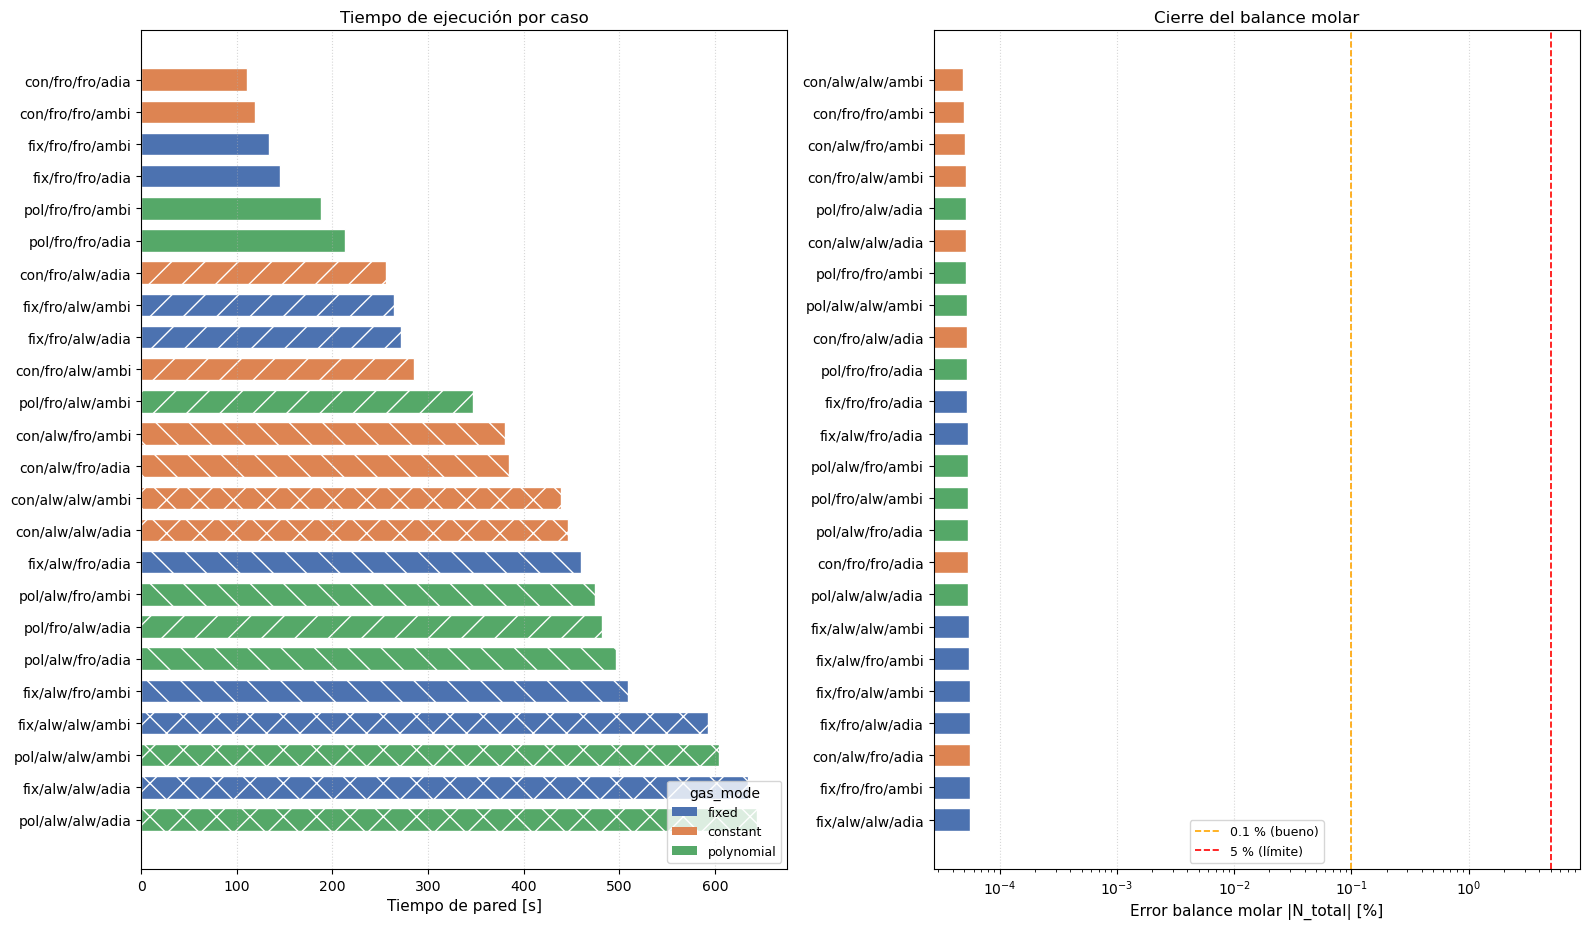

In [8]:
# ── Plot 1: Tiempo de ejecución por caso ──────────────────────────────────
COLOR_MAP = {"fixed": "#4C72B0", "constant": "#DD8452", "polynomial": "#55A868"}
UPDATE_HATCH = {"frozen/frozen": "", "frozen/always": "/", "always/frozen": "\\", "always/always": "x"}

df_plot = df_ok.sort_values("wall_time_s", ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(df_plot) * 0.35 + 1)))

# Panel izquierdo: tiempo de pared
ax = axes[0]
colors  = [COLOR_MAP.get(r, "gray") for r in df_plot["gas_mode"]]
hatches = [UPDATE_HATCH.get(f"{r['prop_update']}/{r['trans_update']}", "")
           for _, r in df_plot.iterrows()]

bars = ax.barh(df_plot["label"], df_plot["wall_time_s"],
               color=colors, edgecolor="white", height=0.7)
for bar, h in zip(bars, hatches):
    bar.set_hatch(h)

ax.set_xlabel("Tiempo de pared [s]", fontsize=11)
ax.set_title("Tiempo de ejecución por caso", fontsize=12)
ax.invert_yaxis()
ax.grid(axis="x", linestyle=":", alpha=0.5)

# Leyenda de colores (gas_mode)
from matplotlib.patches import Patch
legend_gas = [Patch(facecolor=c, label=k) for k, c in COLOR_MAP.items()]
ax.legend(handles=legend_gas, title="gas_mode", loc="lower right", fontsize=9)

# Panel derecho: error de balance molar
ax2 = axes[1]
df_bal_plot = df_ok.sort_values("mol_err_pct", ascending=True).reset_index(drop=True)
colors2 = [COLOR_MAP.get(r, "gray") for r in df_bal_plot["gas_mode"]]

ax2.barh(df_bal_plot["label"], df_bal_plot["mol_err_pct"].clip(lower=1e-10),
         color=colors2, edgecolor="white", height=0.7)
ax2.set_xscale("log")
ax2.set_xlabel("Error balance molar |N_total| [%]", fontsize=11)
ax2.set_title("Cierre del balance molar", fontsize=12)
ax2.invert_yaxis()
ax2.axvline(x=0.1, color="orange", linestyle="--", linewidth=1.2, label="0.1 % (bueno)")
ax2.axvline(x=5.0, color="red",    linestyle="--", linewidth=1.2, label="5 % (límite)")
ax2.grid(axis="x", linestyle=":", alpha=0.5)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

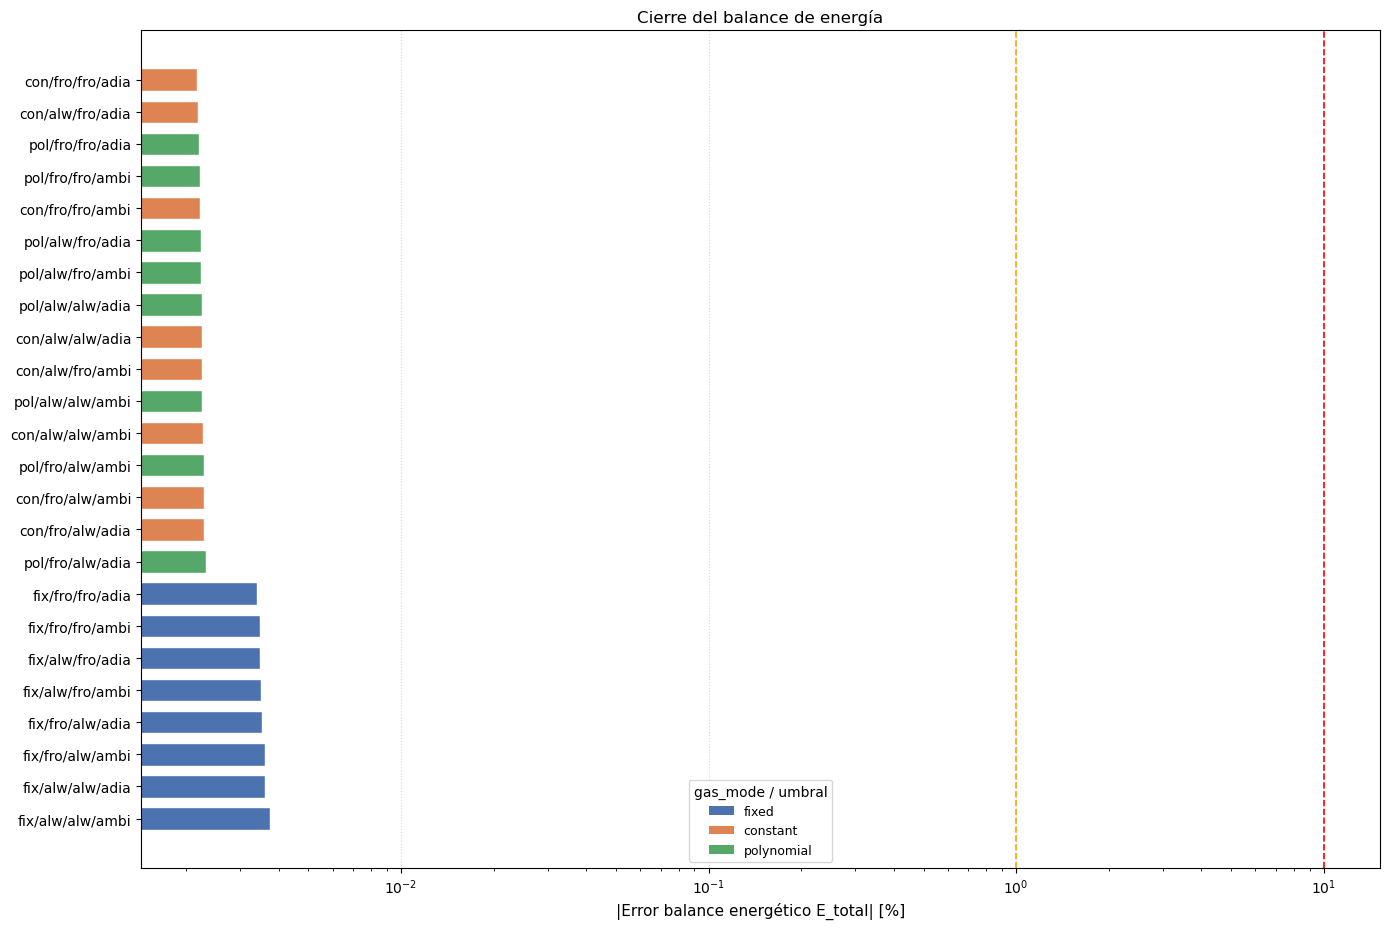

In [9]:
# ── Plot 2: Error de balance energético ───────────────────────────────────
fig, ax = plt.subplots(figsize=(14, max(4, len(df_ok) * 0.35 + 1)))

df_e_plot = df_ok.sort_values("E_err_pct", ascending=True).reset_index(drop=True)
colors_e  = [COLOR_MAP.get(r, "gray") for r in df_e_plot["gas_mode"]]

ax.barh(df_e_plot["label"], df_e_plot["E_err_pct"].clip(lower=1e-10),
        color=colors_e, edgecolor="white", height=0.7)
ax.set_xscale("log")
ax.set_xlabel("|Error balance energético E_total| [%]", fontsize=11)
ax.set_title("Cierre del balance de energía", fontsize=12)
ax.invert_yaxis()
ax.axvline(x=1.0,  color="orange", linestyle="--", linewidth=1.2, label="1 % (aceptable)")
ax.axvline(x=10.0, color="red",    linestyle="--", linewidth=1.2, label="10 % (alto)")
ax.grid(axis="x", linestyle=":", alpha=0.5)
ax.legend(handles=legend_gas + ax.get_legend_handles_labels()[0][2:],
          title="gas_mode / umbral", fontsize=9)

plt.tight_layout()
plt.show()

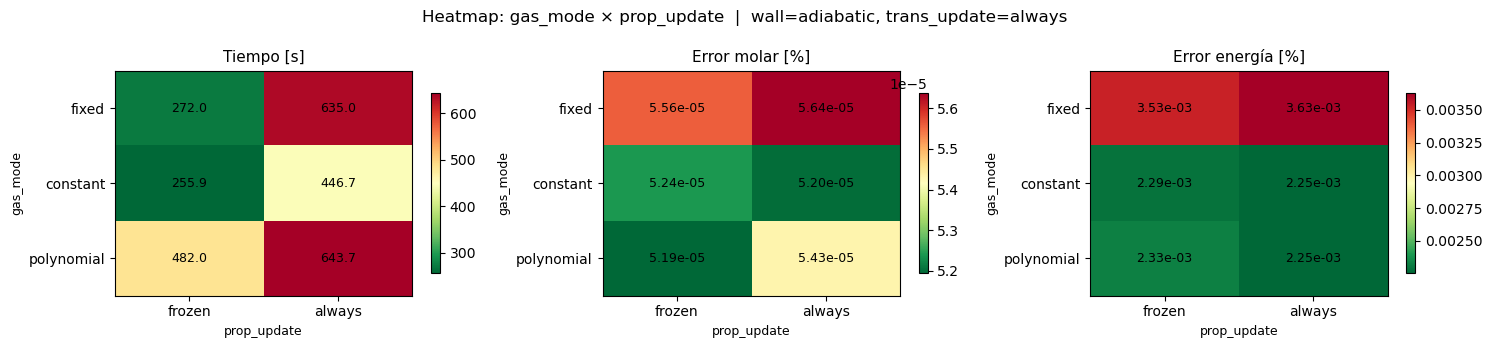

In [10]:
# ── Plot 3: Heatmap tiempo × error para gas_mode × prop_update ────────────
# Fija wall_mode y trans_update para el heatmap (editar si quieres otro corte)
WALL_HEATMAP  = "adiabatic"
TRANS_HEATMAP = "always"

df_hm = df_ok[
    (df_ok["wall_mode"]    == WALL_HEATMAP) &
    (df_ok["trans_update"] == TRANS_HEATMAP)
].copy()

if len(df_hm) == 0:
    print(f"No hay casos OK con wall_mode='{WALL_HEATMAP}' y trans_update='{TRANS_HEATMAP}'")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

    for ax, (metric, title, fmt) in zip(axes, [
        ("wall_time_s", "Tiempo [s]",       "{:.1f}"),
        ("mol_err_pct", "Error molar [%]",  "{:.2e}"),
        ("E_err_pct",   "Error energía [%]", "{:.2e}"),
    ]):
        pivot = df_hm.pivot_table(
            index="gas_mode", columns="prop_update", values=metric, aggfunc="mean"
        )
        # Ordenar filas y columnas
        for gm in GAS_MODES:
            if gm not in pivot.index:
                pivot.loc[gm] = float('nan')
        pivot = pivot.reindex(GAS_MODES)
        for pu in PROP_UPDATE_MODES:
            if pu not in pivot.columns:
                pivot[pu] = float('nan')
        pivot = pivot[PROP_UPDATE_MODES]

        im = ax.imshow(pivot.values.astype(float), aspect="auto",
                       cmap="RdYlGn_r" if metric != "wall_time_s" else "RdYlGn_r")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns, fontsize=10)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index, fontsize=10)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("prop_update", fontsize=9)
        ax.set_ylabel("gas_mode", fontsize=9)
        plt.colorbar(im, ax=ax, shrink=0.8)

        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                val = pivot.values[i, j]
                if not np.isnan(val):
                    ax.text(j, i, fmt.format(val),
                            ha="center", va="center", fontsize=9, color="black")

    fig.suptitle(
        f"Heatmap: gas_mode × prop_update  |  wall={WALL_HEATMAP}, trans_update={TRANS_HEATMAP}",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()

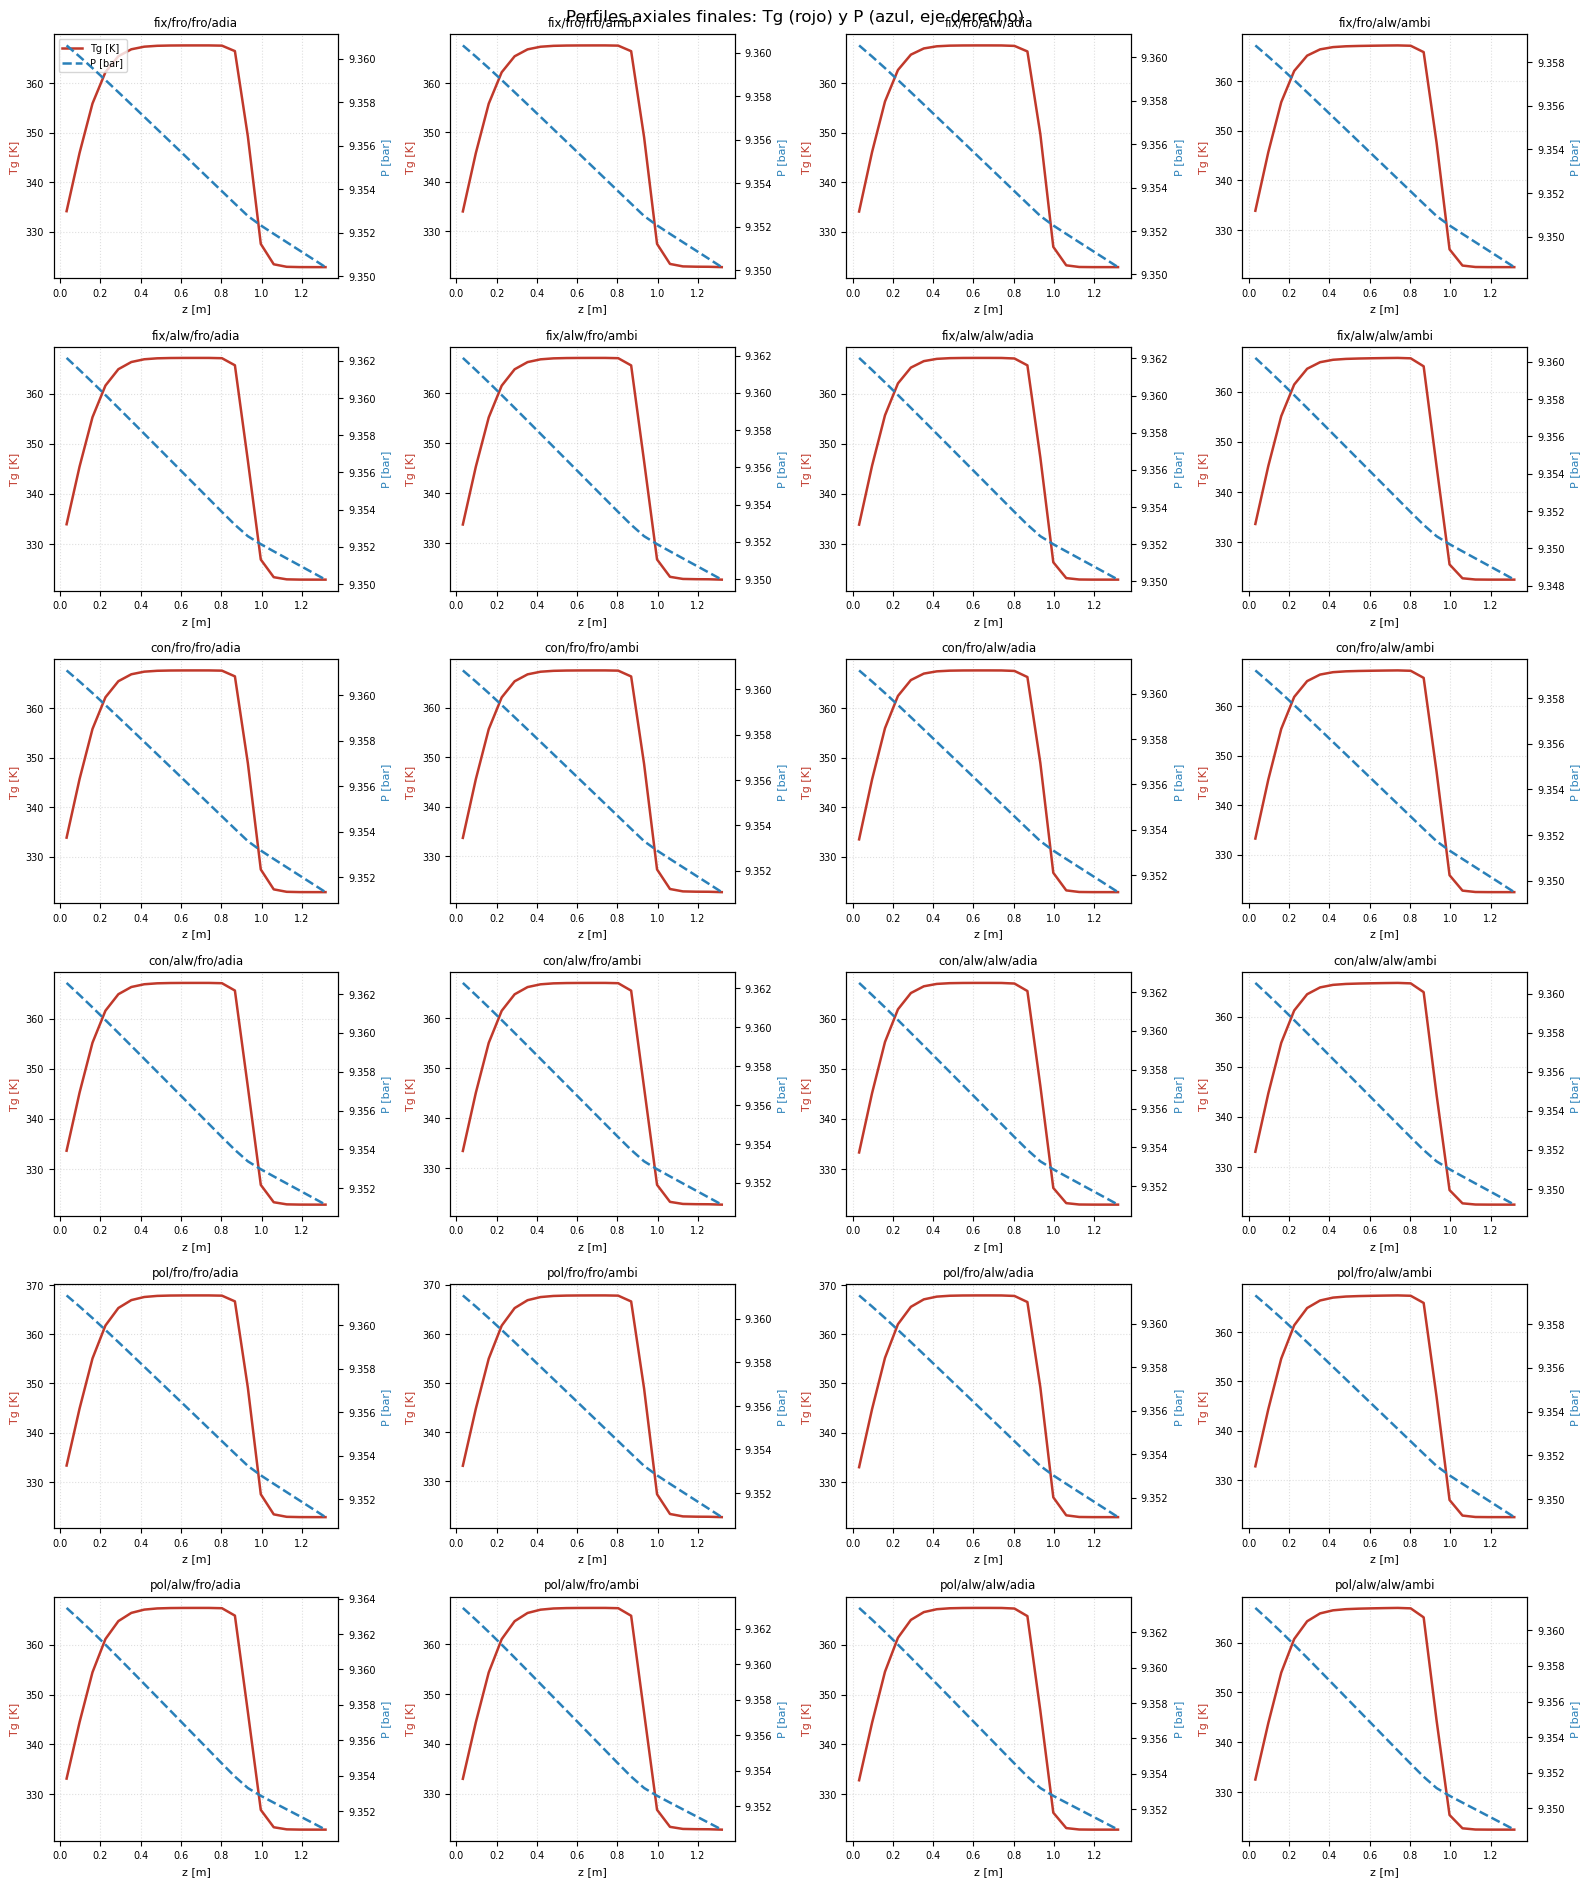

In [11]:
# ── Plot 4: Perfiles axiales finales — grid de casos ─────────────────────
# Muestra perfil de Tg y P al final del paso para cada caso OK
cases_ok = [c for c in CASES if c["name"] in RESULTS]
n_ok     = len(cases_ok)

N_COLS = 4
N_ROWS = -(-n_ok // N_COLS)   # ceil division

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS * 4.0, N_ROWS * 3.2),
                          squeeze=False)

for idx, case in enumerate(cases_ok):
    row_i, col_i = divmod(idx, N_COLS)
    ax = axes[row_i][col_i]

    col_obj = RESULTS[case["name"]]["col"]
    z    = col_obj._z
    Tg_f = col_obj._Tg_results[-1]
    P_f  = col_obj._P_results[-1]

    ax2 = ax.twinx()
    l1, = ax.plot(z, Tg_f,  color="#C0392B", linewidth=1.8, label="Tg [K]")
    l2, = ax2.plot(z, P_f,  color="#2980B9", linewidth=1.8, linestyle="--", label="P [bar]")

    ax.set_title(case["label"], fontsize=8.5)
    ax.set_xlabel("z [m]", fontsize=8)
    ax.set_ylabel("Tg [K]", fontsize=8, color="#C0392B")
    ax2.set_ylabel("P [bar]", fontsize=8, color="#2980B9")
    ax.tick_params(labelsize=7)
    ax2.tick_params(labelsize=7)
    ax.grid(linestyle=":", alpha=0.4)

    if idx == 0:
        ax.legend(handles=[l1, l2], fontsize=7, loc="upper left")

# Ocultar paneles vacíos
for idx in range(n_ok, N_ROWS * N_COLS):
    row_i, col_i = divmod(idx, N_COLS)
    axes[row_i][col_i].set_visible(False)

fig.suptitle("Perfiles axiales finales: Tg (rojo) y P (azul, eje derecho)", fontsize=12)
plt.tight_layout()
plt.show()

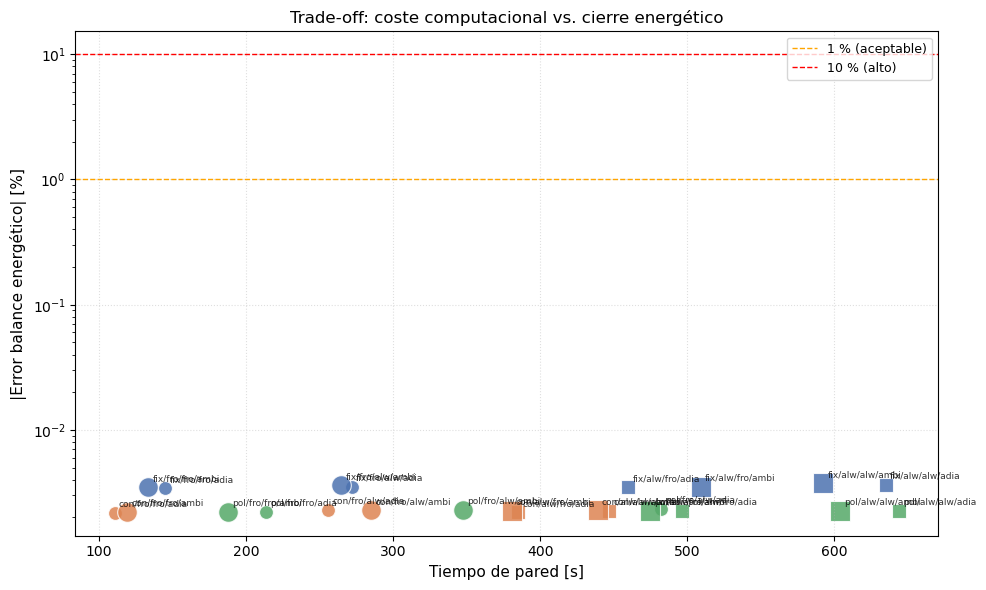

In [12]:
# ── Plot 5: Scatter tiempo vs. error energético — identidad del caso por color ──
if len(df_ok) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    MARKER_MAP = {"frozen": "o", "always": "s"}
    SIZE_MAP   = {"adiabatic": 100, "ambient_htc": 200}

    for _, r in df_ok.iterrows():
        color  = COLOR_MAP.get(r["gas_mode"], "gray")
        marker = MARKER_MAP.get(r["prop_update"], "o")
        size   = SIZE_MAP.get(r["wall_mode"], 100)
        ax.scatter(
            r["wall_time_s"],
            max(r["E_err_pct"], 1e-4),
            color=color, marker=marker, s=size, alpha=0.85, edgecolors="white", linewidths=0.8,
        )
        ax.annotate(
            r["label"], xy=(r["wall_time_s"], max(r["E_err_pct"], 1e-4)),
            fontsize=6.5, ha="left", va="bottom", alpha=0.8,
            xytext=(3, 3), textcoords="offset points",
        )

    ax.set_yscale("log")
    ax.set_xlabel("Tiempo de pared [s]", fontsize=11)
    ax.set_ylabel("|Error balance energético| [%]", fontsize=11)
    ax.set_title("Trade-off: coste computacional vs. cierre energético", fontsize=12)
    ax.axhline(y=1.0,  color="orange", linestyle="--", linewidth=1, label="1 % (aceptable)")
    ax.axhline(y=10.0, color="red",    linestyle="--", linewidth=1, label="10 % (alto)")
    ax.grid(linestyle=":", alpha=0.4)

    legend_elements = (
        [Patch(facecolor=c, label=k) for k, c in COLOR_MAP.items()] +
        [plt.Line2D([0],[0], marker="o", color='w', markerfacecolor='gray',
                   label="prop_update=frozen", ms=8),
         plt.Line2D([0],[0], marker="s", color='w', markerfacecolor='gray',
                   label="prop_update=always", ms=8),
         plt.scatter([],[], s=100, color='gray', label="adiabatic"),
         plt.scatter([],[], s=200, color='gray', label="ambient_htc")]
    )
    ax.legend(handles=legend_elements[:6], fontsize=9, loc="upper left")
    ax.legend(handles=ax.get_lines(), fontsize=9, loc="upper right")

    plt.tight_layout()
    plt.show()

In [13]:
# ── Informe de profiling de funciones (acumulado de todos los casos) ───────
print("\nTop funciones por tiempo total — suma de todos los casos ejecutados:")
df_bench = print_benchmark_functions(top_n=15)


Top funciones por tiempo total — suma de todos los casos ejecutados:
  BENCHMARK DE FUNCIONES  —  15 funciones  |  333,492,570 llamadas totales
  Tiempo instrumentado total: 38247125.22 ms
                           función                                            módulo   llamadas  total [ms]  media [ms]  % tiempo
0                         run_step                     src.solvers.runner_adsorption         24 8884888.648  370203.694    23.230
1                         core_rhs                    src.solvers.rhs.rhs_adsorption    1666073 8260089.347       4.958    21.600
2               wilke_mix_property                src.physics.thermodynamics.mixture    4759880 5504625.491       1.156    14.390
3   compute_gas_mixture_properties                           src.physics.mixture_gas    1152944 4419435.066       3.833    11.550
4    compute_transfer_coefficients  src.units.adsorber.physics.transfer_coefficients    1082984 2850046.544       2.632     7.450
5                        wilke

In [14]:
# ── Resumen: mejor y peor caso por cada métrica ───────────────────────────
if len(df_ok) > 0:
    print("=" * 70)
    print("RESUMEN: MEJOR Y PEOR POR MÉTRICA")
    print("=" * 70)

    for metric, label, best_fn in [
        ("wall_time_s",  "Tiempo de pared [s]",        "idxmin"),
        ("mol_err_pct",  "Error balance molar [%]",    "idxmin"),
        ("E_err_pct",    "Error balance energía [%]",  "idxmin"),
        ("Tg_mean_final","Tg media final [K]",         "idxmax"),
    ]:
        if metric not in df_ok.columns:
            continue
        col_vals = df_ok[metric].dropna()
        if col_vals.empty:
            continue
        best_idx  = getattr(col_vals, best_fn)()
        worst_idx = (getattr(col_vals, "idxmax" if best_fn == "idxmin" else "idxmin"))()
        best_name  = df_ok.loc[best_idx, "name"]
        worst_name = df_ok.loc[worst_idx, "name"]
        best_val   = col_vals[best_idx]
        worst_val  = col_vals[worst_idx]
        print(f"\n{label}")
        print(f"  Mejor  : {best_name}  →  {best_val:.4g}")
        print(f"  Peor   : {worst_name}  →  {worst_val:.4g}")

    print()
    if len(df_ok) > 0:
        print("\nTabla completa ordenada por tiempo de pared:")
        display(
            df_ok[["name", "wall_time_s", "mol_err_pct", "E_err_pct",
                   "P_mean_final", "Tg_mean_final", "Ts_mean_final"]]
            .sort_values("wall_time_s")
            .reset_index(drop=True)
            .style.format({
                "wall_time_s": "{:.1f}",
                "mol_err_pct": "{:.2e}",
                "E_err_pct":   "{:.2e}",
                "P_mean_final":"{:.3f}",
                "Tg_mean_final":"{:.2f}",
                "Ts_mean_final":"{:.2f}",
            })
        )

RESUMEN: MEJOR Y PEOR POR MÉTRICA

Tiempo de pared [s]
  Mejor  : constant__frozen__frozen__adiabatic  →  110.8
  Peor   : polynomial__always__always__adiabatic  →  643.7

Error balance molar [%]
  Mejor  : constant__always__always__ambient_htc  →  4.875e-05
  Peor   : fixed__always__always__adiabatic  →  5.638e-05

Error balance energía [%]
  Mejor  : constant__frozen__frozen__adiabatic  →  0.00218
  Peor   : fixed__always__always__ambient_htc  →  0.003741

Tg media final [K]
  Mejor  : fixed__frozen__always__adiabatic  →  350.6
  Peor   : polynomial__always__always__ambient_htc  →  349.3


Tabla completa ordenada por tiempo de pared:


,name,wall_time_s,mol_err_pct,E_err_pct,P_mean_final,Tg_mean_final,Ts_mean_final
0,constant__frozen__frozen__adiabatic,110.8,5.41e-05,2.18e-03,9.356,350.49,350.47
1,constant__frozen__frozen__ambient_htc,119.4,5.00e-05,2.22e-03,9.356,350.42,350.40
2,fixed__frozen__frozen__ambient_htc,133.6,5.60e-05,3.49e-03,9.355,350.50,350.47
3,fixed__frozen__frozen__adiabatic,145.3,5.32e-05,3.42e-03,9.355,350.57,350.54
4,polynomial__frozen__frozen__ambient_htc,187.7,5.20e-05,2.22e-03,9.356,350.41,350.39
5,polynomial__frozen__frozen__adiabatic,213.6,5.26e-05,2.20e-03,9.356,350.49,350.47
6,constant__frozen__always__adiabatic,255.9,5.24e-05,2.29e-03,9.356,350.46,350.46
7,fixed__frozen__always__ambient_htc,264.9,5.56e-05,3.61e-03,9.353,350.05,350.06
8,fixed__frozen__always__adiabatic,272.0,5.56e-05,3.53e-03,9.355,350.61,350.62
9,constant__frozen__always__ambient_htc,285.0,5.18e-05,2.29e-03,9.354,349.88,349.89


## Conclusiones del benchmark

*(Rellenar después de ejecutar)*

Preguntas guía:

1. **¿Qué combinación es más rápida?** — Ver Plot 1 (timing bar chart)
2. **¿Qué combinación cierra mejor el balance molar?** — Ver Plot 1 derecho
3. **¿Qué combinación cierra mejor el balance energético?** — Ver Plot 2
4. **¿Cuál es el trade-off entre coste y fidelidad?** — Ver Plot 5 (scatter)
5. **¿El perfil axial final es consistente entre modos?** — Ver Plot 4 (grid)
6. **¿Qué función consume más CPU?** — Ver tabla de profiling

---

### Interpretación general esperada

| Modo | Tiempo | Balance molar | Balance energético | Nota |
|------|--------|---------------|-------------------|------|
| `fixed/frozen` | Más rápido | Bueno | Puede ser alto | Física simplificada |
| `constant/frozen` | Rápido | Bueno | Moderado | Compromiso frecuente |
| `constant/always` | Medio | Bueno | Mejor | Recomendado exploración |
| `polynomial/frozen` | Medio | Bueno | Puede ser alto | Cuidado: inconsistencia frozen |
| `polynomial/always` | Más lento | Bueno | Mejor | Máxima fidelidad física |